In [2]:
import pandas as pd

In [3]:
#products.csv
url ="https://drive.google.com/file/d/1kEr6jOe0mXXwC04Y_uhbuLoMvlTGS4ej/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

#orders.csv
url="https://drive.google.com/file/d/1OMG0gAtCG4wLoQKI4Bln3NgsEXA7EDWW/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)


#orderlines.csv
url="https://drive.google.com/file/d/1DEB7OzrYTsPDwOaPoleTyrlu-4uxl8XF/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines = pd.read_csv(path)


#brands.csv
url="https://drive.google.com/file/d/1NjxZDBK4NT4oRbmjeXv6uuyHVi-AwKkQ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)


In [4]:
# making copies of original data set
orders_df=orders.copy()
orderlines_df=orderlines.copy()
products_df=products.copy()
brands_df=brands.copy()


In [5]:
#clean the dataframes
# check for duplicates
orders_df.duplicated().sum()

# 5 rows with missing values in column--'total_paid'
#created_date --need to change 'datetime' datatype
orders_df.info()

#datatype corrected
orders_df['created_date']=pd.to_datetime(orders_df['created_date'])

# check for duplicates
orderlines_df.duplicated().sum()

#'unit_price'--need to change 'float'datatype
#'date'--change to 'datetime' datatype
orderlines_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                293983 non-null  int64 
 1   id_order          293983 non-null  int64 
 2   product_id        293983 non-null  int64 
 3   product_quantity  293983 non-null  int64 
 4   sku               293983 non-null  object
 5   unit_price        293983 non-null  object
 6   date              293983 non-null  object
dtypes: int64(4), object(3)
mem

In [6]:
# product id column contains only 0 value..better to remove this column
orderlines_df['product_id'].sum()

# removed product_id column
orderlines_df = orderlines_df.drop(columns=["product_id"])

In [7]:
# 'date' data type corrected
orderlines_df['date']=pd.to_datetime(orderlines_df['date'])

##there is more than one '.' in the unit_price column
orderlines_df['unit_price'].str.count(r"\.").value_counts()  # 36169 rows with more than one '.'(period)

# Count the rows with more than one `.`
multi_decimal_rows = (orderlines_df['unit_price'].str.count(r"\.")>1).sum()

# Find the percentage of corrupted rows
percent_corrupted = (100 * multi_decimal_rows / orderlines_df.shape[0])
print(f"{percent_corrupted:.2f}% of the rows in our DataFrame have multiple decimal points in the unit_price")
##12.30% of the rows in our DataFrame have multiple decimal points in the unit_price


12.30% of the rows in our DataFrame have multiple decimal points in the unit_price


In [8]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                293983 non-null  int64         
 1   id_order          293983 non-null  int64         
 2   product_quantity  293983 non-null  int64         
 3   sku               293983 non-null  object        
 4   unit_price        293983 non-null  object        
 5   date              293983 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 13.5+ MB


In [9]:
#Boolean mask to find the orders that contain a price with multiple decimal points
multiple_decimal_mask = orderlines_df['unit_price'].str.count(r"\.") > 1
# Apply the boolean mask to the orderlines DataFrame. This way we can find the order_id of all the affected orders.
corrupted_order_ids = orderlines_df.loc[multiple_decimal_mask, "id_order"]
# Keep only the rows that do not have multiple decimal points
orderlines_df = orderlines_df.loc[~orderlines_df['id_order'].isin(corrupted_order_ids)]  #removed the  36169 rows with more than one '.'(period)

orderlines_df.shape[0]   #check for rows after deteting corrupted rows

orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"])   #datatype of 'unit_price' changed to float
#orderlines_df.loc[:, "unit_price"] = pd.to_numeric(orderlines_df["unit_price"],errors='coerce') #use .loc to avoid copy warning

In [10]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_quantity  216250 non-null  int64         
 3   sku               216250 non-null  object        
 4   unit_price        216250 non-null  float64       
 5   date              216250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 11.5+ MB


In [11]:
orders_df = orders_df[~orders_df["order_id"].isin(corrupted_order_ids)] #corrupted rows also removed from orders_df
missing_total_paid = orders_df[orders_df['total_paid'].isna()]  # 4 rows with null values in orders_df

In [12]:
orders_df = orders_df.dropna(axis=0) # removed 4 rows with null values


In [13]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216250 entries, 0 to 293982
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                216250 non-null  int64         
 1   id_order          216250 non-null  int64         
 2   product_quantity  216250 non-null  int64         
 3   sku               216250 non-null  object        
 4   unit_price        216250 non-null  float64       
 5   date              216250 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 11.5+ MB


In [14]:
remove_ids = [427314,431655,447411,448966]  #removed same ids from orderlines_df
orderlines_df = orderlines_df[~orderlines_df['id_order'].isin(remove_ids)]


In [15]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19326 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          19326 non-null  object
 1   name         19326 non-null  object
 2   desc         19319 non-null  object
 3   price        19280 non-null  object
 4   promo_price  19326 non-null  object
 5   in_stock     19326 non-null  int64 
 6   type         19276 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.0+ MB


In [16]:
products_df.duplicated().sum() # there is duplicates in products_df---8746
products_df=products_df.drop_duplicates()  # removed the duplicates

In [17]:
products_df.info() ## found some missing values in --'desc-7','price-50','type-7'--need to change 'price'&'promo_price' datatype
products_df['desc'].isna().sum()  #check the number of null values in 'desc'
products_df.loc[products_df['desc'].isna(),:] #list the row with null values


<class 'pandas.core.frame.DataFrame'>
Index: 10580 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          10580 non-null  object
 1   name         10580 non-null  object
 2   desc         10573 non-null  object
 3   price        10534 non-null  object
 4   promo_price  10580 non-null  object
 5   in_stock     10580 non-null  int64 
 6   type         10530 non-null  object
dtypes: int64(1), object(6)
memory usage: 661.2+ KB


,sku,name,desc,price,promo_price,in_stock,type
16126,WDT0211-A,"Open - Purple 2TB WD 35 ""PC Security Mac hard ...",NaN,107,814.659,0,1298
16128,APP1622-A,Open - Apple Smart Keyboard Pro Keyboard Folio...,NaN,1.568.206,1.568.206,0,1298
17843,PAC2334,Synology DS718 + NAS Server | 10GB RAM,NaN,566.35,5.659.896,0,12175397
18152,KAN0034-A,Open - Kanex USB-C Gigabit Ethernet Adapter Ma...,NaN,29.99,237.925,0,1298
18490,HTE0025,Hyper Pearl 1600mAh battery Mini USB Mirror an...,NaN,24.99,22.99,1,1515
18612,OTT0200,OtterBox External Battery Power Pack 20000 mAHr,NaN,79.99,56.99,1,1515
18690,HOW0001-A,Open - Honeywell thermostat Lyric zonificador ...,NaN,199.99,1.441.174,0,11905404


In [18]:
#product name copied to the 'desc' colum for these 7 empty 'desc' column--better than to delete
products_df.loc[products_df['desc'].isna(), 'desc'] = products_df.loc[products_df['desc'].isna(), 'name']

products_df['price'].isna().sum()
print(f"The missing values in price are {(products_df['price'].isna().value_counts(normalize=True)[True] * 100).round(2)}% of all rows in the DataFrame")
products_df = products_df.loc[~products['price'].isna()] #removing the null price rows using .loc
# products_df = products_df.dropna(subset=['price'])  #option 2:using .dropna

The missing values in price are 0.43% of all rows in the DataFrame


In [20]:
# price column with more than 1 decimal points
price_problems_number = products_df.loc[(products_df.price.astype(str).str.contains(r"\d+\.\d+\.\d+"))|(products_df.price.astype(str).str.contains(r"\d+\.\d{3,}")), :].shape[0]
print(f"The column price has in total {price_problems_number} wrong values. This is {round(((price_problems_number / products_df.shape[0]) * 100), 2)}% of the rows of the DataFrame")


The column price has in total 542 wrong values. This is 5.15% of the rows of the DataFrame


In [21]:
# remove the rows with more than 1 decimal values in price column
products_df = products_df.loc[(~products_df['price'].astype(str).str.contains(r"\d+\.\d+\.\d+"))&(~products_df['price'].astype(str).str.contains(r"\d+\.\d{3,}")), :]
products_df["price"] = pd.to_numeric(products_df["price"])#change the data type to 'float'


In [23]:
# check the decimal points in 'promo_price' column
promo_problems_number = products_df.loc[(products_df['promo_price'].astype(str).str.contains(r"\d+\.\d+\.\d+"))|(products_df['promo_price'].astype(str).str.contains(r"\d+\.\d{3,}")), :].shape[0]
print(f"The column promo_price has in total {promo_problems_number} wrong values. This is {round(((promo_problems_number / products_df.shape[0]) * 100), 2)}% of the rows of the DataFrame")


The column promo_price has in total 9232 wrong values. This is 92.39% of the rows of the DataFrame


In [24]:
products_df = products_df.drop(columns=["promo_price"]) #deleted promo_price column


In [25]:
# Identify which SKUs are "Unknown" in orderlines
unknown_skus_mask = ~orderlines_df['sku'].isin(products_df['sku'])

#Find all order ids that contain at least one of these unknown skus
#  .unique() to get a list of every order id that is "infected"
affected_order_ids = orderlines_df.loc[unknown_skus_mask, 'id_order'].unique()

In [26]:
#Remove the entire orders if it appears in the "affected_order_ids" list
orderlines_df = orderlines_df[~orderlines_df['id_order'].isin(affected_order_ids)]

# Remove the same order ids from oders_df
orders_df = orders_df[~orders_df['order_id'].isin(affected_order_ids)]


In [27]:
orders_df.info()
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185963 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      185963 non-null  int64         
 1   created_date  185963 non-null  datetime64[ns]
 2   total_paid    185963 non-null  float64       
 3   state         185963 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 7.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 205575 entries, 0 to 293982
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                205575 non-null  int64         
 1   id_order          205575 non-null  int64         
 2   product_quantity  205575 non-null  int64         
 3   sku               205575 non-null  object        
 4   unit_price        205575 non-null  float64       
 5   date         

In [40]:
# final check- orders only contains ids that still exist in orderlines
orders_df = orders_df[orders_df['order_id'].isin(orderlines_df['id_order'].unique())]

In [28]:
# update the existing orders dataframe with only completed orders -41701 completed orders
orders_df = orders_df.loc[orders_df['state'] == 'Completed']
orders_df

,order_id,created_date,total_paid,state
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
5,245275,2017-06-28 11:35:37,149.00,Completed
6,245595,2017-01-21 12:52:47,112.97,Completed
...,...,...,...,...
226549,527042,2018-03-14 11:47:50,18.98,Completed
226577,527070,2018-03-14 11:50:48,24.97,Completed
226581,527074,2018-03-14 11:51:42,24.97,Completed
226603,527096,2018-03-14 11:58:40,34.96,Completed


In [29]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41746 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      41746 non-null  int64         
 1   created_date  41746 non-null  datetime64[ns]
 2   total_paid    41746 non-null  float64       
 3   state         41746 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.6+ MB


In [30]:
# filter the orderlines to match only those completed orders
completed_order_ids = orders_df['order_id'].unique()
orderlines_df = orderlines_df.loc[orderlines_df['id_order'].isin(completed_order_ids)]

In [31]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54324 entries, 7 to 293661
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                54324 non-null  int64         
 1   id_order          54324 non-null  int64         
 2   product_quantity  54324 non-null  int64         
 3   sku               54324 non-null  object        
 4   unit_price        54324 non-null  float64       
 5   date              54324 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 2.9+ MB


In [32]:
#merge orders and orderlines table to make sure that every order id in orders_df exist in orderlines_df and vice versa(inner merge).
orders_orderlines=orders_df.merge(orderlines_df, how = 'inner',left_on ='order_id',right_on='id_order')

# order_ids that are in both tables
order_ids = orders_orderlines["order_id"].unique()

# keep those ids in orders
orders_df = orders_df.loc[orders_df["order_id"].isin(order_ids), :]

# keep those ids in orderlines
orderlines_df = orderlines_df.loc[orderlines_df["id_order"].isin(order_ids), :]

In [33]:
# check to make sure both dataframe contain same number of unique order_ids
orders_df["order_id"].nunique(), orderlines_df["id_order"].nunique()

(41701, 41701)

In [34]:
# Exclude orders with unknown products-merge orderlies and products df
orderlines_products= orderlines_df.merge(products_df, how="left", on = "sku")

#count the missing products---no products
orderlines_products['name'].isna().value_counts()

# if any unknown order present use this code to delete
#orders_to_delete =orderlines_products.loc[orderlines_products['name'].isna(), "id_order"].unique()
#orders_df=orders_df.loc[~orders_df['order_id].isin(orders_to_delete),:]
#orderlines_df=orderlines_df.loc[orderlines_df['id_order'].isin(orders_to_delete),:]

,count
name,
False,54324


In [35]:
#create a new column'unit price total'to calculate the total
orderlines_df['unit_price_total']=orderlines_df['unit_price']*orderlines_df['product_quantity']

#grouped by unit price total ,using 'id_order'
grouped_orderlines_df = orderlines_df.groupby('id_order',as_index=False).agg({'unit_price_total': 'sum'})
# as_index=False changesthe return so that the groupby column remains a column (not the index)

In [36]:
merged_df = orders_df.merge(grouped_orderlines_df, left_on="order_id", right_on="id_order")
merged_df['price_difference']=merged_df['total_paid']-merged_df['unit_price_total']
merged_df['price_difference'].mean().round(2)
merged_df.price_difference.describe()

,price_difference
count,41701.000000
mean,4.474808
std,26.046478
min,-165.000000
25%,0.000000
50%,4.990000
75%,6.990000
max,3984.990000


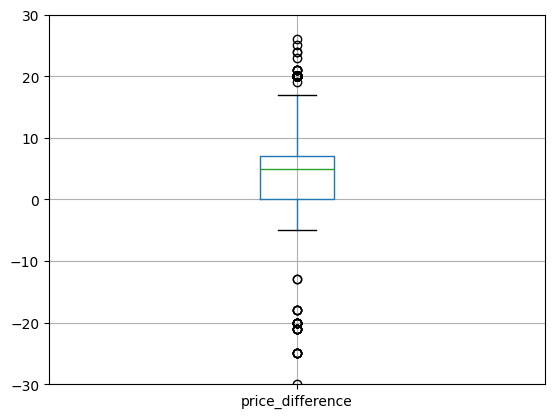

In [37]:
# There's a rule of thumb, that anything:
# lower than the 25% quartile - (1.5 x interquartile range), or
# higher than the 75% quartile + (1.5 x interquartile range)
# is an outlier. Let's use this rule to try and exclude any corrupted data.

# We know this rule from the boxplot
import matplotlib.pyplot as plt

ax = merged_df.boxplot("price_difference");
ax.set_ylim(-30, +30)
plt.show()


In [38]:
# calculate the quartiles
Q1 = merged_df["price_difference"].quantile(0.25)
Q3 = merged_df["price_difference"].quantile(0.75)
Q1, Q3


# calculate the interquartile range
IQR = Q3-Q1
IQR

# lower boundary
Q1 - 1.5*IQR

# upper boundary
Q3 + 1.5*IQR

# filter the DataFrame to include only "non-outliers"
diff_no_outliers_df = merged_df.loc[(merged_df["price_difference"] >= (Q1 - 1.5*IQR))&
    (merged_df["price_difference"] <= (Q3 + 1.5*IQR)),:]

# diff_no_outliers_df.price_difference.hist(bins= 50, figsize=(8,6));
# plt.show()
# diff_no_outliers_df.boxplot("price_difference")
# plt.show()


In [39]:
# Now , need to remove these orders with extreme differences from our orders_lines_merged DataFrame.
normal_diff_list = diff_no_outliers_df["order_id"]
orders_df = orders_df.loc[orders_df["order_id"].isin(normal_diff_list), :]
orderlines_df= orderlines_df.loc[orderlines_df["id_order"].isin(normal_diff_list), :]

orders_df["order_id"].nunique(), orderlines_df["id_order"].nunique()

(40985, 40985)

In [40]:
products_df.info()
orders_df.info()
orderlines_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 19325
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       9992 non-null   object 
 1   name      9992 non-null   object 
 2   desc      9992 non-null   object 
 3   price     9992 non-null   float64
 4   in_stock  9992 non-null   int64  
 5   type      9946 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 546.4+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 40985 entries, 1 to 226619
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      40985 non-null  int64         
 1   created_date  40985 non-null  datetime64[ns]
 2   total_paid    40985 non-null  float64       
 3   state         40985 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 1.6+ MB
<class 'pandas.core.frame.DataFrame'>

In [61]:
# Save the cleaned data and download
# from google.colab import files

# orders_df.to_csv("orders_cl.csv", index=False)
# files.download("orders_cl.csv")

# orderlines_df.to_csv("orderlines_cl.csv", index=False)
# files.download("orderlines_cl.csv")

# products_df.to_csv("products_cl.csv", index=False)
# files.download("products_cl.csv")

# brands_df.to_csv("brands.csv", index=False)
# files.download("brands.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
##Data cleaning finished